In [1]:
# Standard
import os, types
import math
import tempfile
import torch
import time

# Third Party
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed
from transformers.integrations import INTEGRATION_TO_CALLBACK
import numpy as np
import pandas as pd
from botocore.client import Config
from tsfm_public.toolkit.lr_finder import optimal_lr_finder

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# tsfm library
from tsfm_public import (
    TimeSeriesPreprocessor,
    TinyTimeMixerForPrediction,
    TrackingCallback,
    count_parameters,
    get_datasets
)
from tsfm_public.toolkit.visualization import plot_predictions
from tsfm_public.toolkit.get_model import get_model

In [3]:
# Set seed for reproducibility
SEED = 42
set_seed(SEED)

# TTM model branch
TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"

# Forecasting parameters
CONTEXT_LENGTH = 512

# Granite-TTM-R2 supports forecast length upto 720 and Granite-TTM-R1 supports forecast length upto 96
PREDICTION_LENGTH = 96

# Results dir
OUT_DIR = "/TTM/"

In [4]:
timestamp_column = "DATE"
id_columns = []
from pathlib import Path

dataset_name = "youtube_static.csv"
data_file = Path.cwd().parents[1] / "data" / "filtered" / dataset_name

df = pd.read_csv(data_file, parse_dates=["DATE"])
print("Loaded:", data_file)

Loaded: C:\Users\EJ17UF\OneDrive - Aalborg Universitet\Desktop\ms\data\filtered\youtube_static.csv


In [5]:
target_columns = ["mac_dl_brate"]
control_columns = [col for col in df.columns if col not in target_columns]
id_columns = ["ue_ident"]

column_specifiers = {
    "timestamp_column": timestamp_column,
    "id_columns": [],
    "target_columns": ["mac_dl_brate"],
    "control_columns": ["mac_dl_cqi","mac_dl_mcs", "mac_dl_ok","mac_dl_nok",
    ],
}


split_config =  {
    "train": 0.8,
    "test": 0.2,
}

In [6]:
tsp = TimeSeriesPreprocessor(
    **column_specifiers,
    context_length=CONTEXT_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    scaling=True,
    encode_categorical=False,
    scaler_type="minmax",
)

In [7]:
finetune_forecast_model = get_model(
    TTM_MODEL_PATH,
    context_length=CONTEXT_LENGTH,
    prediction_length=PREDICTION_LENGTH,
    num_input_channels=tsp.num_input_channels,
    decoder_mode="mix_channel",  # exog:  set to mix_channel for mixing channels in history
    prediction_channel_indices=tsp.prediction_channel_indices,
    exogenous_channel_indices=tsp.exogenous_channel_indices,
    fcm_context_length=1,  # exog: indicates lag length to use in the exog fusion. for Ex. if today sales can get affected by discount on +/- 2 days, mention 2
    fcm_use_mixer=True,  # exog: Try true (1st option) or false
    fcm_mix_layers=2,  # exog: Number of layers for exog mixing
    enable_forecast_channel_mixing=True,  # exog: set true for exog mixing
    fcm_prepend_past=True,  # exog: set true to include lag from history during exog infusion.
)

INFO:p-884:t-28644:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2


Some weights of TinyTimeMixerForPrediction were not initialized from the model checkpoint at ibm-granite/granite-timeseries-ttm-r2 and are newly initialized: ['decoder.decoder_block.mixers.0.channel_feature_mixer.gating_block.attn_layer.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.gating_block.attn_layer.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc1.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc1.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc2.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc2.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixer.norm.norm.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.norm.norm.weight', 'decoder.decoder_block.mixers.1.channel_feature_mixer.gating_block.attn_layer.bias', 'decoder.decoder_block.mixers.1.channel_feature_mixer.gating_block.attn_layer.weight', 'decoder.decoder_block.mixers.1.channel_feature_mixer.mlp.fc1.bias', 'dec

INFO:p-884:t-28644:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = main.


INFO:p-884:t-28644:get_model.py:get_model:[TTM] context_length = 512, prediction_length = 96


In [8]:
#print(finetune_forecast_model)

In [9]:
import torch.nn as nn

class Adapter(nn.Module):
    def __init__(self, hidden_dim, bottleneck_dim=32):
        super().__init__()
        self.down = nn.Linear(hidden_dim, bottleneck_dim)
        self.up   = nn.Linear(bottleneck_dim, hidden_dim)
        self.act  = nn.GELU()

    def forward(self, x):
        return x + self.up(self.act(self.down(x)))


In [10]:
class TinyTimeMixerLayerWithAdapter(nn.Module):
    def __init__(self, layer, hidden_dim):
        super().__init__()
        self.layer = layer            # original frozen layer
        self.adapter = Adapter(hidden_dim, bottleneck_dim=32)

    def forward(self, x):
        x = self.layer(x)
        x = self.adapter(x)
        return x


In [11]:
def get_hidden_dim(layer):
    return layer.patch_mixer.norm.norm.normalized_shape[0]


In [12]:
encoder_blocks = finetune_forecast_model.backbone.encoder.mlp_mixer_encoder.mixers

for block_idx, block in enumerate(encoder_blocks):
    mixer_layers = block.mixer_layers  # ModuleList of [layer0, layer1]
    
    for layer_idx, layer in enumerate(mixer_layers):
        
        hidden_dim = get_hidden_dim(layer)
        
        # Replace the layer with adapter-wrapped version
        mixer_layers[layer_idx] = TinyTimeMixerLayerWithAdapter(
            layer,
            hidden_dim=hidden_dim
        )


In [13]:
for name, param in finetune_forecast_model.named_parameters():
    if "adapter" in name or name.startswith("head"):
        param.requires_grad = True
    else:
        param.requires_grad = False


In [14]:
# Important parameters


learning_rate = 0.00001
num_epochs = 50 
batch_size = 128

train_dataset, valid_dataset, test_dataset = get_datasets(
    tsp,
    df,
    split_config,
)

In [15]:
print(f"Using learning rate = {learning_rate}")
finetune_forecast_args = TrainingArguments(
    output_dir=os.path.join(OUT_DIR, "output"),
    overwrite_output_dir=True,
    learning_rate=learning_rate,
    num_train_epochs=num_epochs,
    do_eval=True,
    eval_strategy="epoch",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    dataloader_num_workers=8,
    report_to=None,
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    logging_dir=os.path.join(OUT_DIR, "logs"),  # Make sure to specify a logging directory
    load_best_model_at_end=True,  # Load the best model when training ends
    metric_for_best_model="eval_loss",  # Metric to monitor for early stopping
    greater_is_better=False,  # For loss
)

# Create the early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=10,  # Number of epochs with no improvement after which to stop
    early_stopping_threshold=0.0,  # Minimum improvement required to consider as improvement
)
tracking_callback = TrackingCallback()

# Optimizer and scheduler
optimizer = AdamW(filter(lambda p: p.requires_grad, finetune_forecast_model.parameters()), lr=learning_rate)

scheduler = OneCycleLR(
    optimizer,
    learning_rate,
    epochs=num_epochs,
    steps_per_epoch=math.ceil(len(train_dataset) / (batch_size)),
)

finetune_forecast_trainer = Trainer(
    model=finetune_forecast_model,
    args=finetune_forecast_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    callbacks=[early_stopping_callback, tracking_callback],
    optimizers=(optimizer, scheduler),
)

# Fine tune
finetune_forecast_trainer.train()

Using learning rate = 1e-05


C:\Users\EJ17UF\AppData\Local\anaconda3\envs\tf-env\lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.006600,0.055867
2,0.006600,0.056856
3,0.006400,0.058308
4,0.006100,0.060063
5,0.005900,0.062536
6,0.005600,0.064642
7,0.005300,0.066652
8,0.005200,0.068099
9,0.005000,0.068567
10,0.004900,0.068226


C:\Users\EJ17UF\AppData\Local\anaconda3\envs\tf-env\lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


C:\Users\EJ17UF\AppData\Local\anaconda3\envs\tf-env\lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

C:\Users\EJ17UF\AppData\Local\anaconda3\envs\tf-env\lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


C:\Users\EJ17UF\AppData\Local\anaconda3\envs\tf-env\lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


C:\Users\EJ17UF\AppData\Local\anaconda3\envs\tf-env\lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[TrackingCallback] Mean Epoch Time = 552.3213195584037 seconds, Total Train Time = 8450.044004678726


TrainOutput(global_step=2211, training_loss=0.005660868645361353, metrics={'train_runtime': 8450.0472, 'train_samples_per_second': 151.745, 'train_steps_per_second': 1.189, 'total_flos': 3690333389952000.0, 'train_loss': 0.005660868645361353, 'epoch': 11.0})

In [16]:
finetune_forecast_trainer.evaluate(test_dataset)

C:\Users\EJ17UF\AppData\Local\anaconda3\envs\tf-env\lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.002726823789998889,
 'eval_runtime': 178.8591,
 'eval_samples_per_second': 36.163,
 'eval_steps_per_second': 0.285,
 'epoch': 11.0}

In [17]:
raw_timestamps = [item["timestamp"] for item in test_dataset]
test_timestamps = np.array(raw_timestamps)
test_timestamps = pd.to_datetime(test_timestamps)

cutoff = PREDICTION_LENGTH

target_column_index = 0
actuals = np.concatenate(
[item["future_values"].numpy()[:, target_column_index:target_column_index+1] for item in test_dataset],axis=0)

actuals = actuals.reshape(-1, PREDICTION_LENGTH)[:, :cutoff]
print('Actuals Shape', actuals.shape)


# get predictions
predictions_dict = finetune_forecast_trainer.predict(test_dataset)
predictions_np = predictions_dict.predictions[0]

predictions = predictions_dict.predictions

predictions = predictions[0]
predictions = predictions_np[:, :, target_column_index]
predictions = predictions.reshape(-1, PREDICTION_LENGTH)[:, :cutoff]
print('Predictions Shape', predictions.shape)

actuals_avg = np.mean(actuals, axis=1)
predictions_avg = np.mean(predictions, axis=1)

rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)
print('RMSE', rmse)
print('MAE', mae)


Actuals Shape (6468, 96)


C:\Users\EJ17UF\AppData\Local\anaconda3\envs\tf-env\lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predictions Shape (6468, 96)
RMSE 0.052218976068977574
MAE 0.033448219299316406


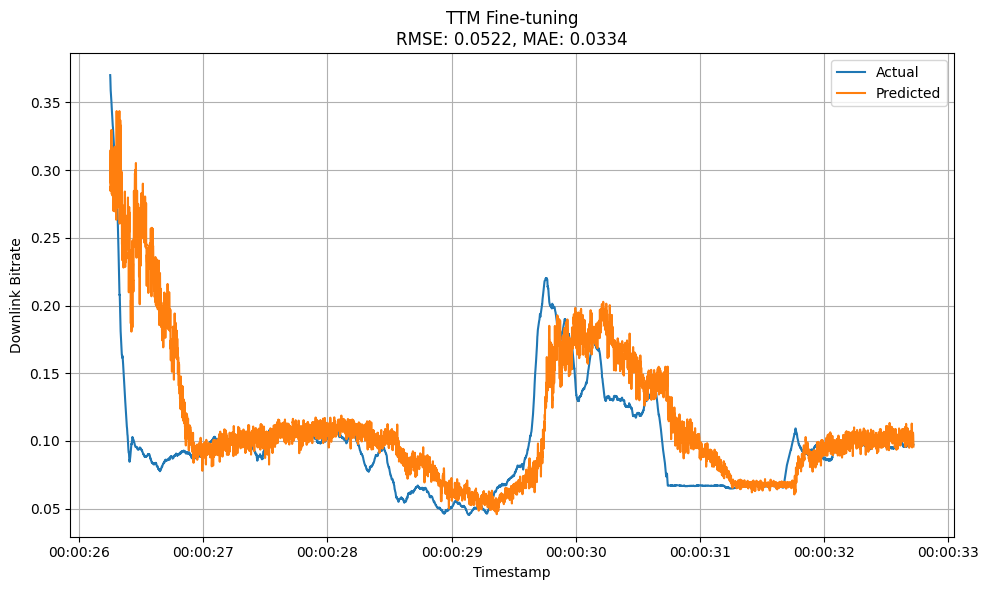

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(test_timestamps, actuals_avg, label='Actual')
plt.plot(test_timestamps, predictions_avg, label='Predicted')
plt.legend()
plt.xlabel('Timestamp')
plt.ylabel('Downlink Bitrate')
plt.title(f'TTM Fine-tuning\nRMSE: {rmse:.4f}, MAE: {mae:.4f}')
plt.grid(True)
plt.tight_layout()
plt.show()

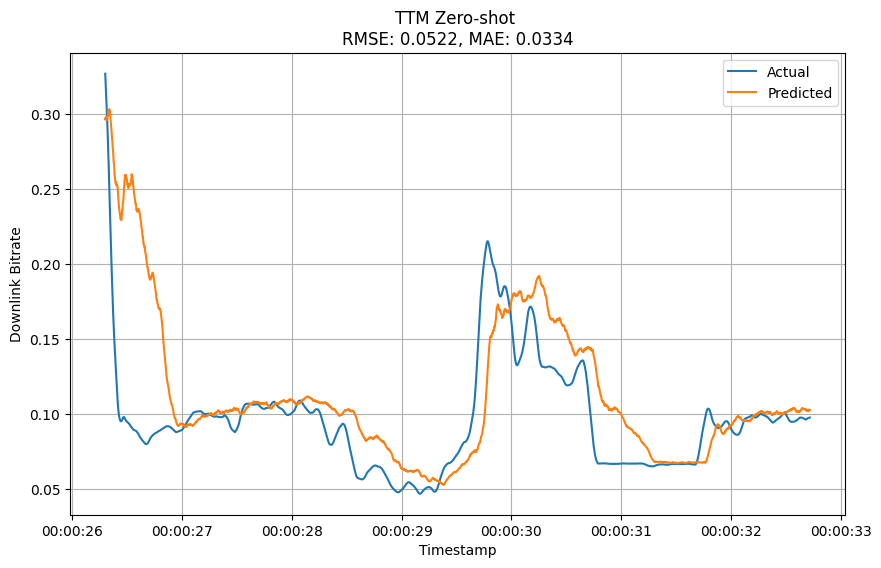

In [19]:
test_smooth = pd.Series(actuals_avg.ravel()).rolling(window=50).mean()
pred_smooth = pd.Series(predictions_avg.ravel()).rolling(window=50).mean()

plt.figure(figsize=(10, 6))
plt.plot(test_timestamps, test_smooth, label='Actual')
plt.plot(test_timestamps, pred_smooth, label='Predicted')
plt.legend()
plt.xlabel('Timestamp')
plt.ylabel('Downlink Bitrate')
plt.title(f'TTM Zero-shot \nRMSE: {rmse:.4f}, MAE: {mae:.4f}')
plt.grid(True)
plt.show()

In [20]:
results_dir = Path("../results/metrics/ttm-finetuning")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame([{
    "model": "TTM-Finetuning",
    "setting": "multivariate",
    "dataset": "youtube_static",
    "rmse": rmse,
    "mae": mae,
}])

metrics_file = results_dir / "ttm_adapterbased_metrics.csv"
metrics_df.to_csv(metrics_file, index=False)

print("Saved metrics to:", metrics_file)

Saved metrics to: ..\results\metrics\ttm-finetuning\ttm_adapterbased_metrics.csv
